In [7]:
pip install notebook

In [2]:
jupyter notebook

SyntaxError: invalid syntax (3305369356.py, line 1)

In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [9]:
import pandas as pd

# The previous unzip extracted 'train.csv', so we'll read that file.
df = pd.read_csv("train.csv")

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [16]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

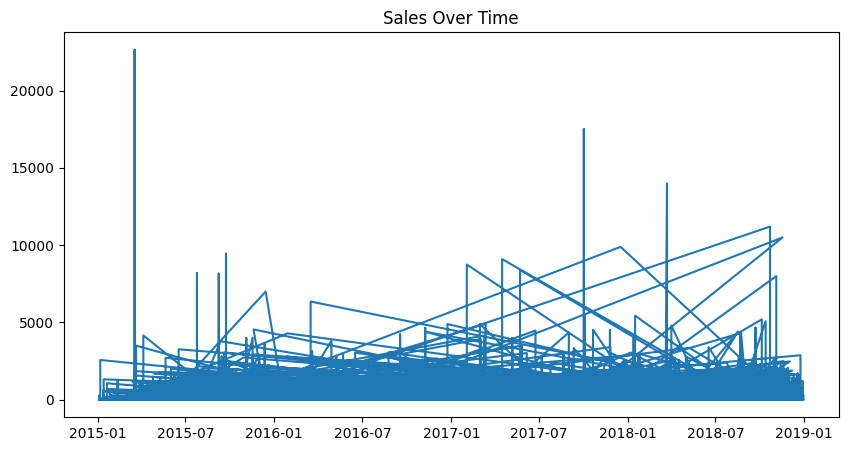

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Order Date'], df['Sales'])
plt.title("Sales Over Time")
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['Year','Month','Day']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [20]:
predictions = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test,predictions)

print(error)

270.2995888876136


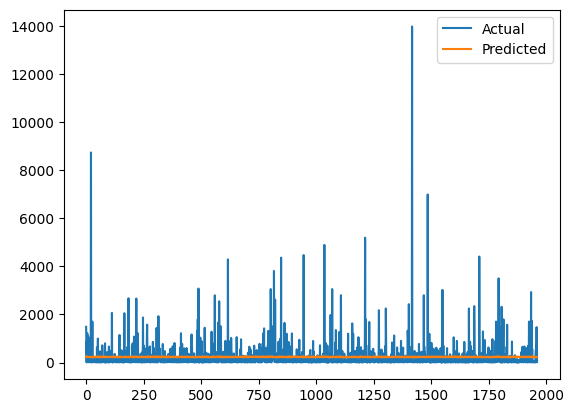

In [22]:
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()

In [24]:
yearly_avg_sales = df.groupby('Year')['Sales'].mean().reset_index()
display(yearly_avg_sales)

,Year,Sales
0,2015,245.702103
1,2016,223.569832
2,2017,236.855781
3,2018,221.624315
